Scanning runs_preflid ...
Scanning: /Users/larkin/code/gale_shapley/runs_preflid
  Found: config='001_N3_K3_b31000', seed=0
  Found: config='001_N3_K3_b31000', seed=1
  Found: config='001_N3_K3_b31000', seed=10
  Found: config='001_N3_K3_b31000', seed=11
  Found: config='001_N3_K3_b31000', seed=12
  Found: config='001_N3_K3_b31000', seed=13
  Found: config='001_N3_K3_b31000', seed=14
  Found: config='001_N3_K3_b31000', seed=15
  Found: config='001_N3_K3_b31000', seed=16
  Found: config='001_N3_K3_b31000', seed=17
  Found: config='001_N3_K3_b31000', seed=18
  Found: config='001_N3_K3_b31000', seed=19
  Found: config='001_N3_K3_b31000', seed=2
  Found: config='001_N3_K3_b31000', seed=20
  Found: config='001_N3_K3_b31000', seed=21
  Found: config='001_N3_K3_b31000', seed=22
  Found: config='001_N3_K3_b31000', seed=23
  Found: config='001_N3_K3_b31000', seed=24
  Found: config='001_N3_K3_b31000', seed=25
  Found: config='001_N3_K3_b31000', seed=26
  Found: config='001_N3_K3_b31000', seed=2

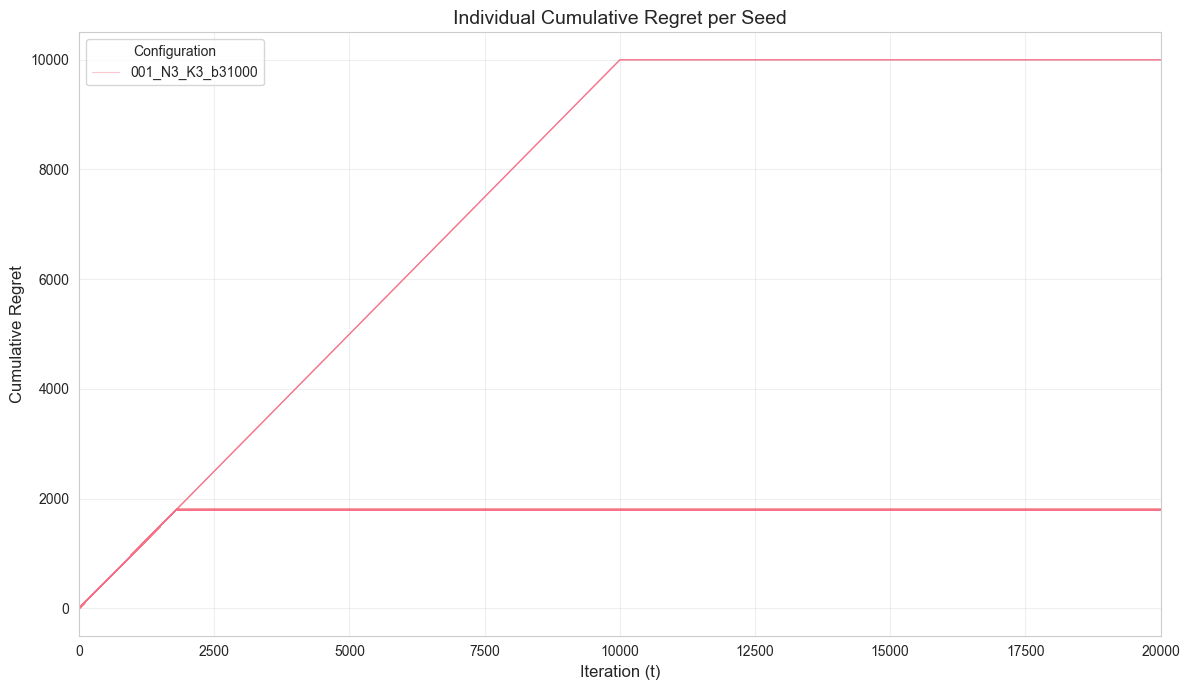

Saved: plots/mean_regret_std.png


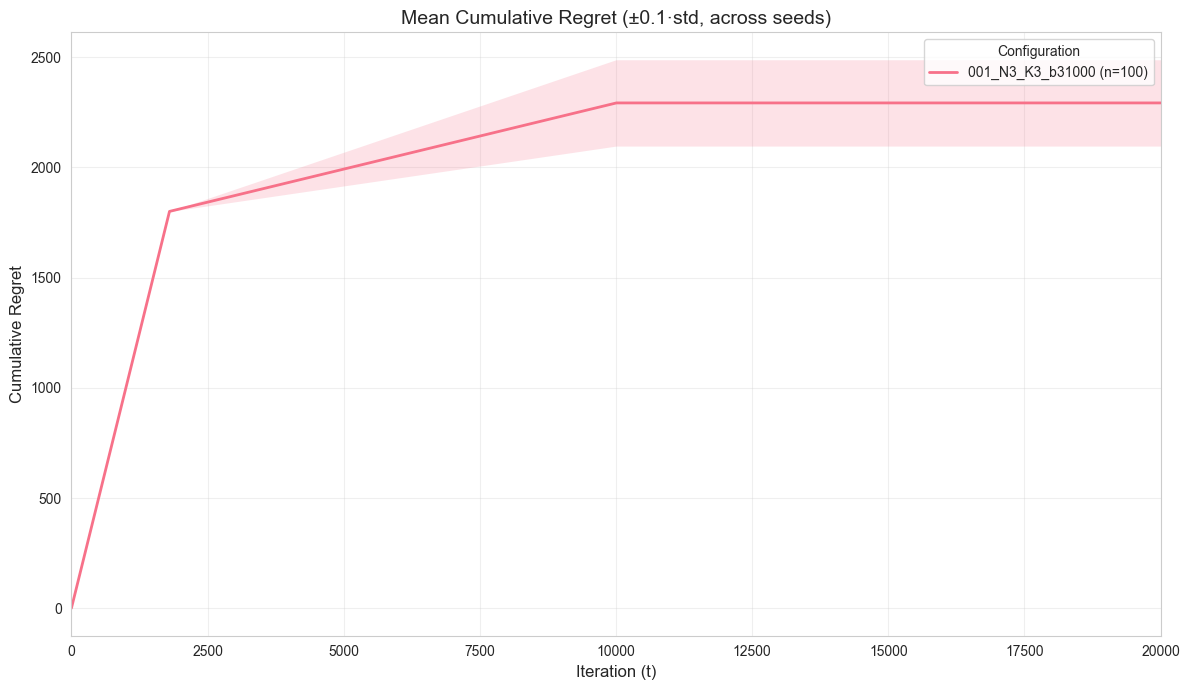

Saved: plots/summary_stats.png


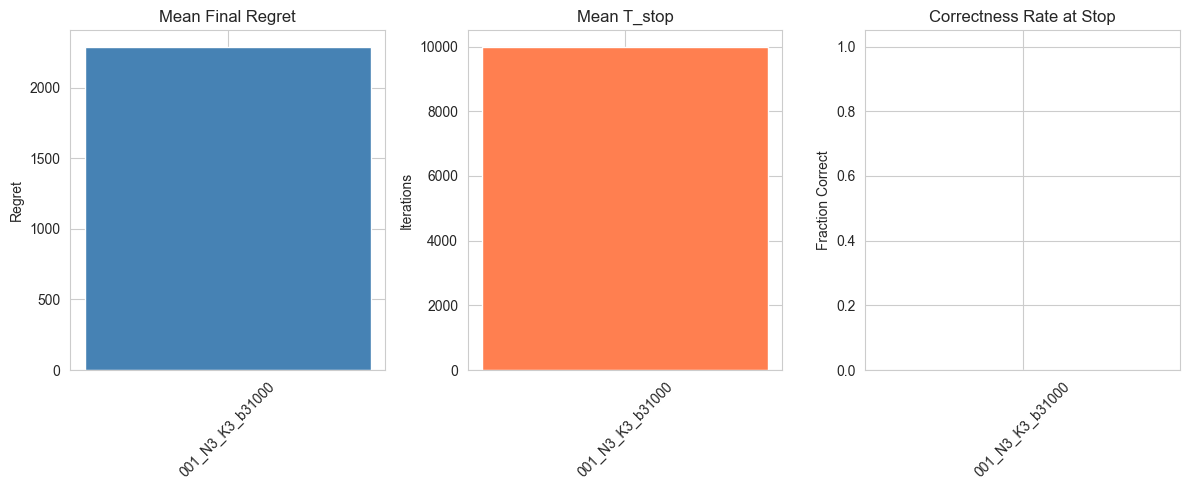

(<Figure size 1200x500 with 3 Axes>,
 array([<Axes: title={'center': 'Mean Final Regret'}, ylabel='Regret'>,
        <Axes: title={'center': 'Mean T_stop'}, ylabel='Iterations'>,
        <Axes: title={'center': 'Correctness Rate at Stop'}, ylabel='Fraction Correct'>],
       dtype=object))

In [64]:
# regret_plotting.py

# import os
# import json
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path
# import re

from plotting import *

# ---- CONFIGURE THIS ----
BASE_DIR = "runs_preflid"   # <-- change me
MAX_ITERATIONS = 20000
OUTPUT_DIR = "plots"                # where to save figures
# ------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load all data
print(f"Scanning {BASE_DIR} ...")
all_data = load_all_configs(BASE_DIR, max_iterations=MAX_ITERATIONS)

if not all_data:
    raise SystemExit("No configuration folders found. Check BASE_DIR.")

print(f"Found {len(all_data)} configurations:")
for cfg, seeds in all_data.items():
    print(f"  {cfg}: {len(seeds)} seeds")

# 1) Individual regret curves
plot_individual_regrets(
    all_data,
    max_iterations=MAX_ITERATIONS,
    save_path=os.path.join(OUTPUT_DIR, "individual_regrets.png"),
)

# 2) Mean ± std regret curves
plot_mean_regret_with_std(
    all_data,
    max_iterations=MAX_ITERATIONS,
    save_path=os.path.join(OUTPUT_DIR, "mean_regret_std.png"),
    std_multiplier=0.1,
    show_individual=False,   # <-- no individual seed lines
)

# 3) Summary stats
plot_summary_stats(
    all_data,
    save_path=os.path.join(OUTPUT_DIR, "summary_stats.png"),
)

Saved: plots/mean_regret_std.png


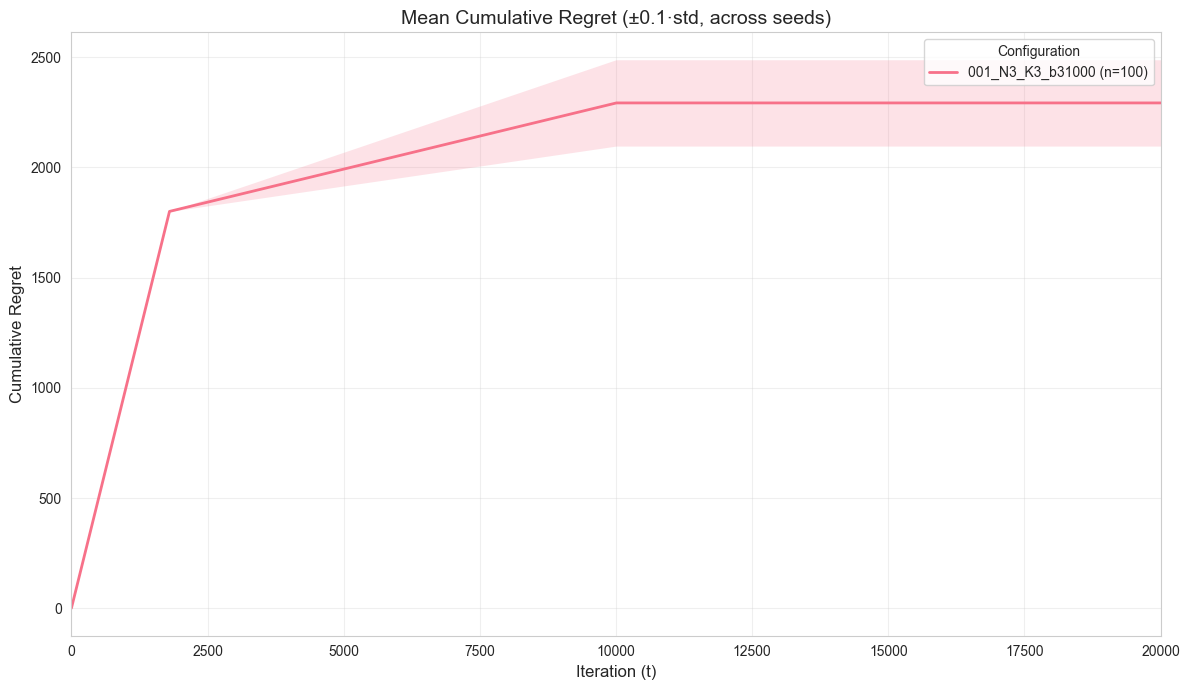

(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'Mean Cumulative Regret (±0.1·std, across seeds)'}, xlabel='Iteration (t)', ylabel='Cumulative Regret'>)

In [65]:
LABELS = {
    "N3_K3_a2.0": "N=3, K=3, α=2.0",
    "N5_K5_a2.0": "N=5, K=5, α=2.0",
}

plot_mean_regret_with_std(
    all_data,
    max_iterations=MAX_ITERATIONS,
    show_individual=False,
    labels=LABELS,
        save_path=os.path.join(OUTPUT_DIR, "mean_regret_std.png"),
        std_multiplier=0.1,
)